# Fusion estimator benchmark

This notebook drives every estimator in `sensor_fusion` through the
common `run_simulation` harness against the full `TRAJECTORY_CATALOG`
(`straight`, `circle`, `sine`, `zigzag`, `figure8`, `stopgo`) at every
`NoiseLevel` preset (`IDEAL`, `LOW`, `MEDIUM`, `HIGH`).

The four estimators compared:

| Name | What it does |
|---|---|
| `kf` | Linear Kalman filter, bias-aware (`KalmanFusion2D`) |
| `imu_only` | Pure IMU dead reckoning — the drift baseline |
| `wheel_only` | Wheel velocity dead reckoning — no IMU correction |
| `complementary` | Complementary filter blending IMU + wheel (`wheel_weight=0.2`) |

Sections below produce:

1. A heatmap of position-RMS error per (estimator × trajectory) at
   the `MEDIUM` noise preset.
2. A heatmap per (estimator × noise level) on the sine trajectory.
3. Trajectory overlays for a hard case (`zigzag`, `HIGH` noise) so the
   failure modes are visible.
4. Per-step timing comparison.

In [1]:
import sys
from pathlib import Path

# This notebook lives in `sensor_fusion/`; force the repo root to be
# `sys.path[0]` so that `from simulation import ...` finds the harness
# at the repo root rather than failing on a stale namespace package.
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "simulation.py").exists() else NB_DIR.parent
repo_root_str = str(REPO_ROOT)
while repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

import numpy as np
import matplotlib.pyplot as plt

from config import (
    NoiseLevel,
    SimulationConfig,
    imu_config_for,
    wheel_config_for,
)
from robot import TRAJECTORY_CATALOG
from sensor_fusion import (
    ComplementaryNoise,
    FusionMode,
    SensorFusion,
    make_fusion,
)
from simulation import run_simulation

# Mode-specific tuning that the factory should pass through.
COMPLEMENTARY_TUNING = ComplementaryNoise(wheel_weight=0.2)

MODE_COLORS = {
    FusionMode.KF:            "#1f77b4",
    FusionMode.IMU_ONLY:      "#d62728",
    FusionMode.ODOMETRY_ONLY: "#2ca02c",
    FusionMode.COMPLEMENTARY: "#9467bd",
}

MODES = list(FusionMode)
TRAJ_NAMES = list(TRAJECTORY_CATALOG)
NOISE_LEVELS = list(NoiseLevel)

print("Repo root:", REPO_ROOT)
print("Fusion modes:", [m.value for m in MODES])
print("Trajectories:", TRAJ_NAMES)
print("Noise levels:", [lvl.value for lvl in NOISE_LEVELS])

Repo root: /home/zhihua.zhang/test/sensor_fusion/sensor_fusion_challenge
Estimators: ['kf', 'imu_only', 'wheel_only', 'complementary']
Trajectories: ['straight', 'circle', 'sine', 'zigzag', 'figure8', 'stopgo']
Noise levels: ['ideal', 'low', 'medium', 'high']


## 1. Run the full benchmark grid

96 runs total (4 estimators × 6 trajectories × 4 noise levels), each
8 s of simulated time at 1 kHz IMU / 50 Hz wheel odometry.  Results
are cached in a single dictionary so later cells can re-use them
without re-running the simulations.

In [2]:
import time as _time

SIM_DURATION_S = 8.0
SIM_SEED = 7
IMU_HZ = 1000.0
WHEEL_HZ = 50.0

sim_cfg_base = SimulationConfig(duration_s=SIM_DURATION_S, seed=SIM_SEED)

# results[(mode, trajectory, noise_level)] -> SimulationResult
results: dict[tuple[FusionMode, str, NoiseLevel], object] = {}

t0 = _time.perf_counter()
for traj_name in TRAJ_NAMES:
    trajectory = TRAJECTORY_CATALOG[traj_name]
    for level in NOISE_LEVELS:
        imu_cfg = imu_config_for(level, rate_hz=IMU_HZ)
        wheel_cfg = wheel_config_for(level, rate_hz=WHEEL_HZ)
        for mode in MODES:
            results[(mode, traj_name, level)] = run_simulation(
                f"{mode.value}/{traj_name}/{level.value}",
                sim_config=sim_cfg_base,
                imu_config=imu_cfg,
                wheel_config=wheel_cfg,
                trajectory=trajectory,
                fusion_mode=mode,
                complementary_noise=COMPLEMENTARY_TUNING,
            )
elapsed = _time.perf_counter() - t0
print(f"Ran {len(results)} simulations in {elapsed:.2f} s "
      f"({len(results)*SIM_DURATION_S*IMU_HZ/1e6:.2f} M total IMU steps)")

Ran 96 simulations in 5.15 s (0.77 M total IMU steps)


## 2. Heatmap: estimator vs trajectory (`MEDIUM` noise)

For each (estimator, trajectory) cell we show the position RMS error.
The intentionally drifty baselines should stand out clearly here.

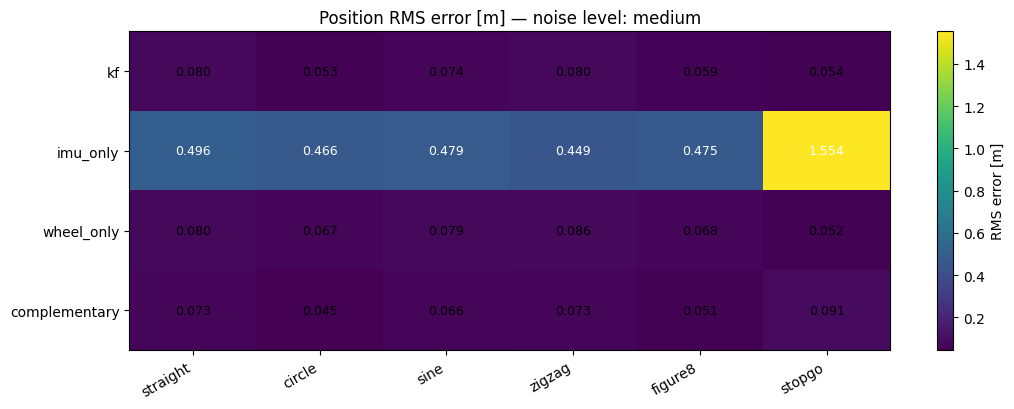

In [3]:
def heatmap(ax, data: np.ndarray, row_labels, col_labels, title, fmt="{:.3f}"):
    im = ax.imshow(data, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(col_labels)), col_labels, rotation=30, ha="right")
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(
                j, i, fmt.format(data[i, j]),
                ha="center", va="center",
                color="white" if data[i, j] > data.mean() else "black",
                fontsize=9,
            )
    return im


level = NoiseLevel.MEDIUM
rms_grid = np.array(
    [
        [results[(mode, traj, level)].rms_position_error_m for traj in TRAJ_NAMES]
        for mode in MODES
    ]
)

fig, ax = plt.subplots(figsize=(11, 4.2))
im = heatmap(
    ax, rms_grid,
    row_labels=[m.value for m in MODES],
    col_labels=TRAJ_NAMES,
    title=f"Position RMS error [m] — noise level: {level.value}",
)
fig.colorbar(im, ax=ax, label="RMS error [m]")
fig.tight_layout()
plt.show()

## 3. Heatmap: estimator vs noise level (sine trajectory)

Holding the trajectory fixed and sweeping the noise preset isolates
how each estimator scales with sensor quality.  `imu_only` should
explode as we move from `IDEAL` to `HIGH`; the Kalman filter should
degrade gracefully.

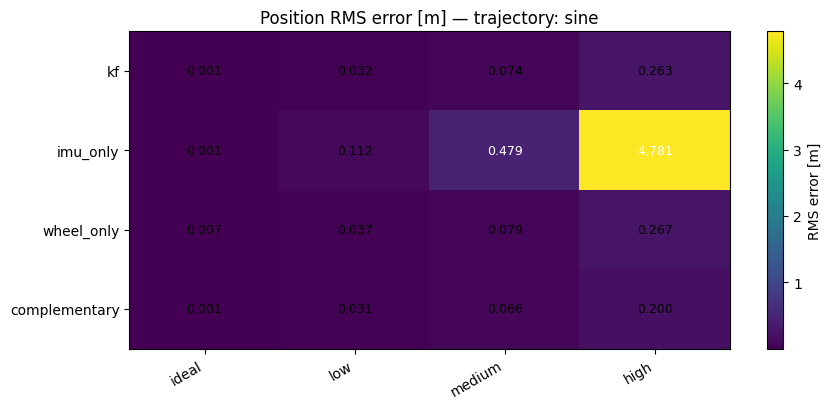

In [4]:
traj = "sine"
rms_grid = np.array(
    [
        [results[(mode, traj, lvl)].rms_position_error_m for lvl in NOISE_LEVELS]
        for mode in MODES
    ]
)

fig, ax = plt.subplots(figsize=(9, 4.2))
im = heatmap(
    ax, rms_grid,
    row_labels=[m.value for m in MODES],
    col_labels=[lvl.value for lvl in NOISE_LEVELS],
    title=f"Position RMS error [m] — trajectory: {traj}",
    fmt="{:.3f}",
)
fig.colorbar(im, ax=ax, label="RMS error [m]")
fig.tight_layout()
plt.show()

## 4. Trajectory overlays (hard case: `zigzag` @ `HIGH` noise)

Numerical RMS is one thing; seeing each estimator's actual path is
another.  Below, all four estimates are overlaid on the ground truth
for the hardest scenario in the grid: zigzag motion with the cheap-MEMS
noise preset.

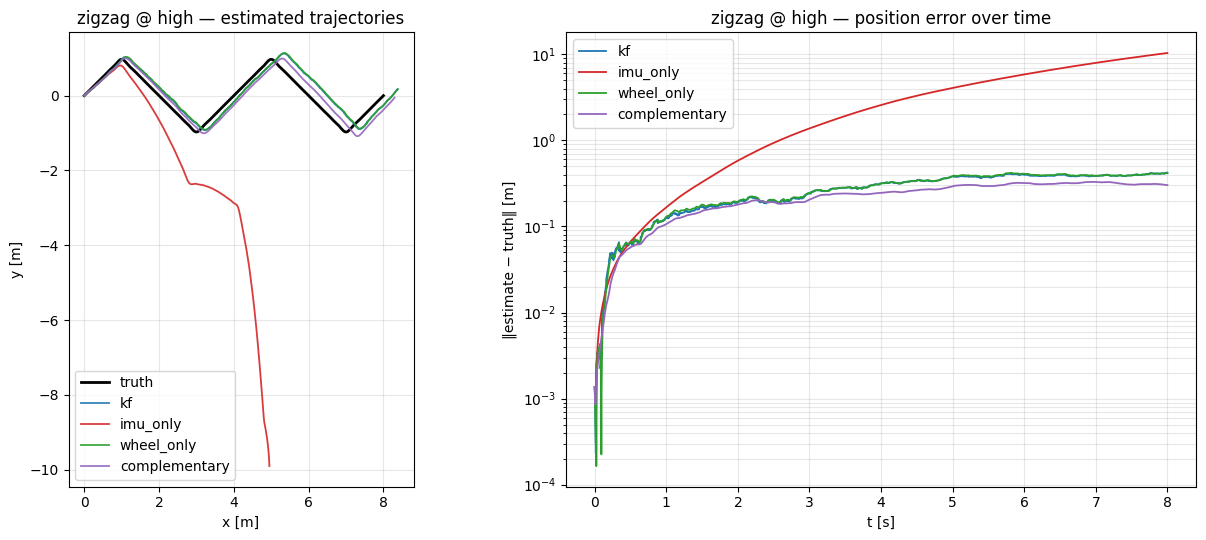

In [5]:
show_traj = "zigzag"
show_level = NoiseLevel.HIGH

truth = results[(FusionMode.KF, show_traj, show_level)].truth_position  # same for all modes

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# (a) Trajectory plot
ax = axes[0]
ax.plot(truth[:, 0], truth[:, 1], color="k", lw=2.0, label="truth")
for mode in MODES:
    pos = results[(mode, show_traj, show_level)].estimate_position
    ax.plot(pos[:, 0], pos[:, 1], color=MODE_COLORS[mode], lw=1.3, alpha=0.9,
            label=mode.value)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
ax.set_title(f"{show_traj} @ {show_level.value} — estimated trajectories")

# (b) Position error vs time
ax = axes[1]
for mode in MODES:
    r = results[(mode, show_traj, show_level)]
    err = np.linalg.norm(r.estimate_position - r.truth_position, axis=1)
    ax.plot(r.time_s, err, color=MODE_COLORS[mode], lw=1.3, label=mode.value)
ax.set_xlabel("t [s]")
ax.set_ylabel("‖estimate − truth‖ [m]")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best")
ax.set_title(f"{show_traj} @ {show_level.value} — position error over time")

fig.tight_layout()
plt.show()

## 5. Per-step timing

The fusion code runs in the 1 kHz IMU loop, so per-step cost matters.
This is the mean time of `predict(...) + occasional update_wheel_velocity(...)`,
averaged across all 24 (trajectory × noise) cells for each estimator.

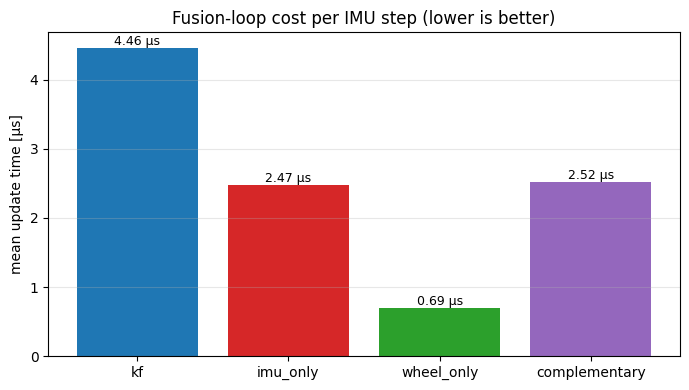

Mean update time per estimator (µs):
              kf    4.46
        imu_only    2.47
      wheel_only    0.69
   complementary    2.52


In [6]:
timing = {
    mode: float(np.mean(
        [results[(mode, t, lvl)].mean_update_time_us
         for t in TRAJ_NAMES for lvl in NOISE_LEVELS]
    ))
    for mode in MODES
}

fig, ax = plt.subplots(figsize=(7, 4))
labels = [m.value for m in timing]
heights = [timing[m] for m in timing]
bars = ax.bar(labels, heights, color=[MODE_COLORS[m] for m in timing])
ax.set_ylabel("mean update time [µs]")
ax.set_title("Fusion-loop cost per IMU step (lower is better)")
for bar, h in zip(bars, heights):
    ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.2f} µs",
            ha="center", va="bottom", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print("Mean update time per fusion mode (µs):")
for mode, us in timing.items():
    print(f"  {mode.value:>14}  {us:6.2f}")

## 6. Numeric summary

Full grid as a flat table — handy for grepping or pasting into a report.

In [7]:
rows = []
for mode in MODES:
    for traj in TRAJ_NAMES:
        for lvl in NOISE_LEVELS:
            r = results[(mode, traj, lvl)]
            rows.append({
                "mode": mode.value,
                "trajectory": traj,
                "noise": lvl.value,
                "rms_m": r.rms_position_error_m,
                "final_m": r.final_position_error_m,
                "us_per_step": r.mean_update_time_us,
            })

try:
    import pandas as pd
    df = pd.DataFrame(rows)
    pivot = df.pivot_table(
        index=["trajectory", "noise"],
        columns="mode",
        values="rms_m",
    ).round(4)
    display(pivot)
except ImportError:
    print(f"{'mode':>14}  {'trajectory':>10}  {'noise':>7}  "
          f"{'rms_m':>8}  {'final_m':>8}  {'us/step':>8}")
    for r in rows:
        print(f"{r['mode']:>14}  {r['trajectory']:>10}  {r['noise']:>7}  "
              f"{r['rms_m']:8.4f}  {r['final_m']:8.4f}  {r['us_per_step']:8.2f}")

     estimator  trajectory    noise     rms_m   final_m   us/step
            kf    straight    ideal    0.0010    0.0010      4.53
            kf    straight      low    0.0355    0.0454      4.52
            kf    straight   medium    0.0801    0.0989      4.51
            kf    straight     high    0.3015    0.4156      4.45
            kf      circle    ideal    0.0010    0.0010      4.43
            kf      circle      low    0.0220    0.0273      4.43
            kf      circle   medium    0.0527    0.0680      4.50
            kf      circle     high    0.1760    0.2103      4.42
            kf        sine    ideal    0.0010    0.0010      4.44
            kf        sine      low    0.0322    0.0374      4.44
            kf        sine   medium    0.0740    0.0838      4.45
            kf        sine     high    0.2634    0.3315      4.45
            kf      zigzag    ideal    0.0014    0.0014      4.44
            kf      zigzag      low    0.0357    0.0460      4.46
          